In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
n = h5py.File('H-H1_GWOSC_16KHZ_R1-1257294808-4096_new.hdf5', 'r+')

In [3]:
n.keys()

<KeysViewHDF5 ['meta', 'quality', 'strain']>

In [4]:
n['strain'].keys()

<KeysViewHDF5 ['GWOSCmeta', 'Strain']>

In [5]:
del n['strain']['Strain']

In [6]:
n['strain'].keys()

<KeysViewHDF5 ['GWOSCmeta']>

In [9]:
o = h5py.File('H-H1_GWOSC_16KHZ_R1-1257294808-4096.hdf5')

In [10]:
old_strain = o['strain']['Strain']
truncated = old_strain[30031872:]

In [11]:
n['strain'].create_dataset('Strain', data=truncated)

<HDF5 dataset "Strain": shape (37076992,), type "<f8">

In [12]:
n['strain'].keys()

<KeysViewHDF5 ['GWOSCmeta', 'Strain']>

In [13]:
new_gps = 1257296641

In [17]:
float(n['meta']['GPSstart'][()])

1257294808.0

In [18]:
n['meta']['GPSstart'][...] = new_gps

In [19]:
float(n['meta']['GPSstart'][()])

1257296641.0

In [20]:
n['meta']['GPSstart']

<HDF5 dataset "GPSstart": shape (), type "<i8">

In [21]:
n['meta'].keys()

<KeysViewHDF5 ['Description', 'DescriptionURL', 'Detector', 'Duration', 'GPSstart', 'Observatory', 'Type', 'UTCstart']>

In [24]:
float(n['meta']['Duration'][()])

4096.0

In [25]:
new_duration = 2263

In [26]:
n['meta']['Duration'][...] = new_duration

In [27]:
float(n['meta']['Duration'][()])

2263.0

In [37]:
l = h5py.File('L-L1_GWOSC_16KHZ_R1-1257294808-4096.hdf5')

In [41]:
time = float(n['meta/GPSstart'][()]) + np.arange(len(n['strain']['Strain']))/16384.
strain = n['strain']['Strain'][:]
print(len(time), len(strain))

37076992 37076992


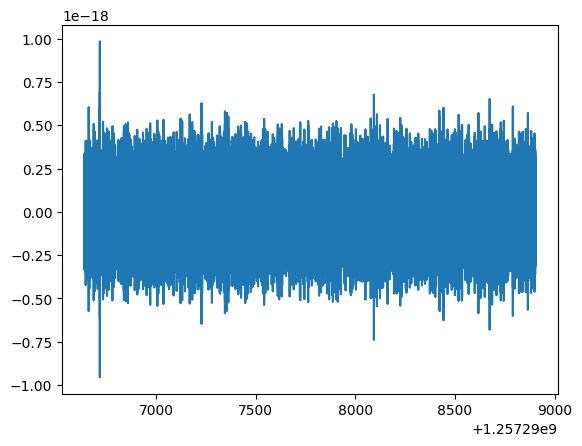

In [35]:
plt.plot(time, strain)

In [44]:
l_strain = l['strain']['Strain'][:]
time_l = float(l['meta/GPSstart'][()]) + np.arange(len(l['strain']['Strain']))/16384

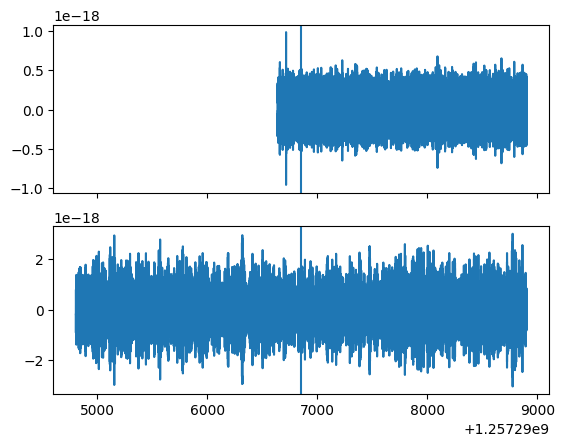

In [45]:
fig, axes = plt.subplots(2, 1, sharex=True)
axes[0].plot(time, strain)
axes[1].plot(time_l, l_strain)

axes[0].axvline(x=1257296855.2)
axes[1].axvline(x=1257296855.2)